# Verification — phase-space reconstruction

## 1. Frozen configuration

Primary: **901 valid processed PPG windows 60 s, 20 sessions**. Nominal **m=8, τ=0.16 s** đã freeze trước sensitivity;
không chọn lại tham số theo p-value hoặc effect.

| Thành phần | Cấu hình giữ nguyên |
|---|---|
| Delay grid | τ ∈ {0.12, 0.16, 0.20} s; downstream cố định m=8 |
| Dimension grid | m ∈ {7, 8, 9}; downstream cố định τ=0.16 s |
| FNN | m=1–10; R_tol=15; A_tol=2; Theiler=0; threshold=1% |
| Simplex | 18 horizons 0.04–4 s; k=m+1; Theiler=1 s; Euclidean; normalized exponential weighting; leave-one-out |
| Signal normalization | Processed signal; window z-score ddof=0; NRMSE scale=1 |
| RQA | Euclidean; fixed RR=0.02; l_min=v_min=2; Theiler=(m−1)×tau_samples |
| LLE | Rosenstein; fit 0.80–1.30 s; follow 5 s; spectral mean-period Theiler; minimum pairs 50/30; R²≥0.90 |
| Inference | Median paired Δ; percentile bootstrap 20,000; two-sided Wilcoxon; signed r_rb; BH riêng cho 4 metric trong mỗi setting |

Đổi giây sang sample bằng `round(seconds × fs)` với fs thực tế. Không thay preprocessing, SQI, stationarity hoặc labels;
không PPS, refilter hay resegmentation. Các figure chỉ inline.

Các output final dưới đây được giữ từ lần chạy đã hoàn tất. Bản clean chỉ sắp xếp lại source/output, không execute hoặc recompute.

In [ ]:
from pathlib import Path
import hashlib, json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import rankdata, wilcoxon

def require(condition, message):
    if not condition:
        raise ValueError(message)

ROOT = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
             if (p / 'phase1/src/dataloader/loader.py').is_file()), None)
require(ROOT is not None, 'Cannot locate repository root.')
PHASE1 = ROOT / 'phase1'
SRC = PHASE1 / 'src'
DATA_DIR = PHASE1 / 'segmentated_data/dhdata'
TAUS = (0.12, 0.16, 0.20)
NOMINAL_TAU, M, WINDOW_S = 0.16, 8, 60
FNN_CONFIG = dict(max_m=10, r_tol=15.0, a_tol=2.0, theiler=0, fnn_threshold=1.0)
DIMENSIONS = np.arange(1, FNN_CONFIG['max_m'] + 1)
HORIZONS_S = np.array([.04,.08,.12,.16,.20,.28,.40,.60,.80,1.,1.2,1.6,2.,2.4,2.8,3.2,3.6,4.])
PREDICTION_THEILER_S = 1.0
RQA_CONFIG = dict(l_min=2, v_min=2, target_rr=0.02)
LLE_CONFIG = dict(fit_start_s=.80, fit_end_s=1.30, max_follow_s=5.,
                  min_initial_pairs=50, min_fit_pairs=30, min_r2=.90)
METRICS = ('Mean_CC', 'Mean_NRMSE', 'DET', 'LLE')
EXPECTED_SIGN = dict(Mean_CC=-1, Mean_NRMSE=1, DET=-1, LLE=-1)
N_BOOT, SEED = 20_000, 20_260_829

mpl.rcParams.update({'font.family':'serif', 'font.serif':['DejaVu Serif'],
    'font.size':10, 'axes.labelsize':10, 'axes.titlesize':10,
    'xtick.labelsize':9, 'ytick.labelsize':9, 'legend.fontsize':9,
    'figure.dpi':150, 'figure.facecolor':'white', 'axes.facecolor':'white',
    'axes.spines.top':False, 'axes.spines.right':False, 'axes.grid':False})

CORE_PATHS = ['dataloader/loader.py', 'embedding/fnn.py', 'embedding/psr.py',
              'prediction/simplex_projection.py', 'rqa/rqa.py', 'chaos/lyapunov.py']
CORE_HASHES = {name: hashlib.sha256((SRC / name).read_bytes()).hexdigest() for name in CORE_PATHS}
CONFIG = dict(taus=TAUS, m=M, window_s=WINDOW_S, fnn=FNN_CONFIG,
              horizons_s=HORIZONS_S.tolist(), prediction_theiler_s=PREDICTION_THEILER_S,
              rqa=RQA_CONFIG, lle=LLE_CONFIG, cores=CORE_HASHES)
CONFIG_HASH = hashlib.sha256(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()
M_GRID = (7, 8, 9)
M_NOMINAL = 8
M_TAU_S = 0.16
M_BOOTSTRAPS = 20_000
M_SEED = 20_260_829
M_METRICS = ('Mean_CC', 'Mean_NRMSE', 'DET', 'LLE')
M_EXPECTED_SIGN = dict(Mean_CC=-1, Mean_NRMSE=1, DET=-1, LLE=-1)

M_RUN_CONFIG = dict(primary_config_hash=CONFIG_HASH, dimensions=M_GRID,
    nominal_m=M_NOMINAL,tau_s=M_TAU_S,aggregation='window horizon mean -> session-state median',
    bootstrap_resamples=M_BOOTSTRAPS,seed=M_SEED)
M_CONFIG_HASH = hashlib.sha256(json.dumps(M_RUN_CONFIG,sort_keys=True).encode()).hexdigest()

display(pd.DataFrame([
    ['FNN', 'notebook/fnn.ipynb', str(FNN_CONFIG)],
    ['Prediction', 'notebook/simplex_projection.ipynb', '18 horizons, W=1 s; window z-score ddof=0; NRMSE scale=1'],
    ['RQA', 'notebook/rqa.ipynb', 'Euclidean; RR=.02; l_min=v_min=2; Theiler=(m-1)*tau_samples'],
    ['LLE', 'notebook/lyapunov.ipynb; main/lle_main.ipynb', 'fit .80–1.30 s; follow 5 s; spectral mean-period Theiler; R²>=.90'],
], columns=['Method','Primary source (phase1/)','Frozen parameters']))

,Method,Primary source (phase1/),Frozen parameters
0,FNN,notebook/fnn.ipynb,"{'max_m': 10, 'r_tol': 15.0, 'a_tol': 2.0, 'th..."
1,Prediction,notebook/simplex_projection.ipynb,"18 horizons, W=1 s; window z-score ddof=0; NRM..."
2,RQA,notebook/rqa.ipynb,Euclidean; RR=.02; l_min=v_min=2; Theiler=(m-1...
3,LLE,notebook/lyapunov.ipynb; main/lle_main.ipynb,fit .80–1.30 s; follow 5 s; spectral mean-peri...


## 2. Load primary / cached results

Dùng lại các bảng window-level đã hoàn tất trong kernel hoặc phục hồi chúng từ `CACHE` / `M_CACHE` cùng fingerprint.
Không load/filter lại signal và không có fallback tính estimator. Cache hiện có là RAM; nếu kernel mới chưa nạp cache,
các output đã lưu vẫn là hồ sơ kết quả để đọc/audit. Bảng coverage dưới đây giữ nguyên từ primary loader.

In [ ]:
# Read completed result tables only; never call an estimator or batch runner.
if 'fnn_windows' not in globals():
    cached_fnn=[value for key,value in globals().get('CACHE',{}).items()
                if key[0]==CONFIG_HASH and key[1]=='fnn' and key[-1] in TAUS]
    require(bool(cached_fnn), 'Completed FNN table/cache is not loaded in this kernel.')
    fnn_windows=pd.concat(cached_fnn,ignore_index=True)

if 'downstream_windows' not in globals():
    cached_tau=[value[0] for key,value in globals().get('CACHE',{}).items()
                if key[0]==CONFIG_HASH and key[1]=='downstream' and key[-1] in TAUS]
    require(bool(cached_tau), 'Completed tau downstream table/cache is not loaded in this kernel.')
    downstream_windows=pd.DataFrame(cached_tau)

if 'm_windows' not in globals():
    cached_m=[value[0] for key,value in globals().get('M_CACHE',{}).items()
              if key[0]==M_CONFIG_HASH and key[1]=='dimension'
              and key[-2]==M_TAU_S and key[-1] in M_GRID]
    require(bool(cached_m), 'Completed m downstream table/cache is not loaded in this kernel.')
    m_windows=pd.DataFrame(cached_m)

nominal_windows=downstream_windows.loc[downstream_windows.tau_s.eq(NOMINAL_TAU)
                                     & downstream_windows['m'].eq(M)].copy()
N_WINDOWS=len(nominal_windows)
SESSIONS=sorted(nominal_windows.session.unique(),key=lambda s:int(s.rsplit('_',1)[1]))
M_SESSIONS=list(SESSIONS)
require(N_WINDOWS==901 and len(SESSIONS)==20, 'Primary cohort differs from the completed verification.')
require(len(fnn_windows)==N_WINDOWS*len(TAUS)*len(DIMENSIONS), 'Incomplete FNN results.')
require(len(downstream_windows)==N_WINDOWS*len(TAUS), 'Incomplete tau results.')
require(len(m_windows)==N_WINDOWS*len(M_GRID), 'Incomplete dimension results.')
require(downstream_windows.window_size_s.eq(WINDOW_S).all()
        and downstream_windows['m'].eq(M).all(), 'Tau-sensitivity frozen scope changed.')
require(m_windows.window_size_s.eq(WINDOW_S).all()
        and m_windows.tau_s.eq(M_TAU_S).all(), 'Dimension-sensitivity frozen scope changed.')
require(set(downstream_windows.tau_s)==set(TAUS) and set(m_windows['m'])==set(M_GRID), 'Grid mismatch.')
require(not downstream_windows.duplicated(['session','state','window_id','tau_s']).any(), 'Duplicate tau results.')
require(not m_windows.duplicated(['session','state','window_id','m']).any(), 'Duplicate dimension results.')
coverage=nominal_windows.groupby('session',sort=False,as_index=False).agg(
    n_windows=('window_id','size'),Awake=('state',lambda s:int(s.eq('Awake').sum())),
    Drowsy=('state',lambda s:int(s.eq('Drowsy').sum())),fs=('fs','first'))
display(coverage)

,session,n_windows,Awake,Drowsy,fs
0,sample_1,31,24,7,50.000000
1,sample_4,46,29,17,24.991878
2,sample_5,49,33,16,25.002500
3,sample_6,48,31,17,24.993127
4,sample_7,45,34,11,24.993752
5,sample_8,46,36,10,24.993752
6,sample_9,65,47,18,25.000625
7,sample_10,36,27,9,24.998236
8,sample_11,38,20,18,24.993767
9,sample_12,55,20,35,24.989380


## 3. FNN robustness

Giữ đầy đủ summary τ×m và bảng trọng tâm m=7,8,9. Mỗi session đóng góp một median FNN tại mỗi (τ,m);
đường trung tâm/IQR được tổng hợp giữa session. Core chọn m theo ≤1%; tỷ lệ session trong bảng dùng **<1%**.
Không thay threshold hoặc chọn lại m theo kết quả downstream.

In [ ]:
require(len(fnn_windows)==N_WINDOWS*len(TAUS)*len(DIMENSIONS), 'Incomplete full FNN batch')
require(not fnn_windows.duplicated(['session','window_id','tau_s','dimension']).any(), 'FNN duplicates')
fnn_session = fnn_windows.groupby(['session','tau_s','dimension'],as_index=False).agg(
    fnn_percent=('fnn_percent','median'), n_windows=('window_id','nunique'))
fnn_summary = fnn_session.groupby(['tau_s','dimension'],as_index=False).agg(
    median=('fnn_percent','median'), q25=('fnn_percent',lambda s:s.quantile(.25)),
    q75=('fnn_percent',lambda s:s.quantile(.75)), n_sessions=('session','nunique'),
    n_below_1=('fnn_percent',lambda s:int(s.lt(1.).sum())))
fnn_summary['iqr'] = fnn_summary.q75-fnn_summary.q25
fnn_summary['pct_sessions_below_1'] = 100*fnn_summary.n_below_1/fnn_summary.n_sessions
require(fnn_summary.n_sessions.eq(len(SESSIONS)).all(), 'FNN session coverage missing')
fnn_evidence_rows=[]
for tau in TAUS:
    s = fnn_summary.loc[fnn_summary.tau_s.eq(tau)].set_index('dimension')
    curves=fnn_session.loc[fnn_session.tau_s.eq(tau)].pivot(index='session',columns='dimension',values='fnn_percent')
    fnn_evidence_rows.append(dict(tau_s=tau, FNN_m7=s.loc[7,'median'], FNN_m8=s.loc[8,'median'],
        FNN_m9=s.loc[9,'median'], m8_q25=s.loc[8,'q25'], m8_q75=s.loc[8,'q75'],
        sessions_below_1=f"{int(s.loc[8,'n_below_1'])}/{len(SESSIONS)}",
        pct_sessions_below_1=s.loc[8,'pct_sessions_below_1'],
        gain_1_to_8_pp=(curves[1]-curves[8]).median(),
        gain_7_to_8_pp=(curves[7]-curves[8]).median(),
        gain_8_to_9_pp=(curves[8]-curves[9]).median(),
        conclusion='Review decline and plateau; not automatically classified'))
fnn_evidence=pd.DataFrame(fnn_evidence_rows)
display(fnn_summary, fnn_evidence)

,tau_s,dimension,median,q25,q75,n_sessions,n_below_1,iqr,pct_sessions_below_1
0,0.12,1,95.991984,95.440882,96.258593,20,0,0.817712,0.0
1,0.12,2,27.945114,26.497657,29.283802,20,0,2.786145,0.0
2,0.12,3,7.075788,6.632479,7.251844,20,0,0.619365,0.0
3,0.12,4,2.234543,1.814516,2.536962,20,0,0.722446,0.0
4,0.12,5,1.043771,0.841751,1.212121,20,8,0.370370,40.0
5,0.12,6,0.792848,0.598853,0.919366,20,18,0.320513,90.0
6,0.12,7,0.659229,0.498648,0.819811,20,19,0.321163,95.0
7,0.12,8,0.592818,0.499742,0.762195,20,19,0.262453,95.0
8,0.12,9,0.577054,0.466735,0.797692,20,19,0.330957,95.0
9,0.12,10,0.646259,0.493197,0.884354,20,18,0.391156,90.0


,tau_s,FNN_m7,FNN_m8,FNN_m9,m8_q25,m8_q75,sessions_below_1,pct_sessions_below_1,gain_1_to_8_pp,gain_7_to_8_pp,gain_8_to_9_pp,conclusion
0,0.12,0.659229,0.592818,0.577054,0.499742,0.762195,19/20,95.0,95.330940,0.016251,-0.001414,Review decline and plateau; not automatically ...
1,0.16,0.900136,0.885559,1.007514,0.613079,1.132493,11/20,55.0,94.981986,-0.001897,-0.088267,Review decline and plateau; not automatically ...
2,0.20,1.092150,1.284247,1.443299,0.881978,1.438356,7/20,35.0,94.512530,-0.105779,-0.142988,Review decline and plateau; not automatically ...


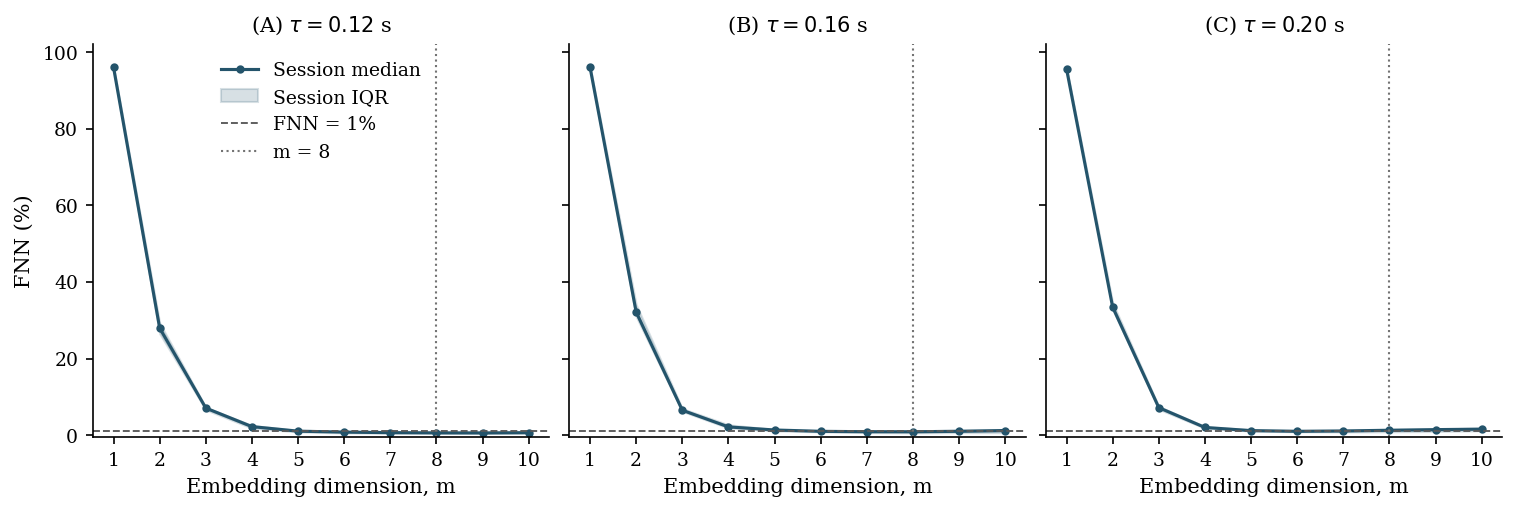

In [9]:
fig, axes=plt.subplots(1,3,figsize=(10,3.3),sharex=True,sharey=True,layout='constrained')
for ax,tau,label in zip(axes,TAUS,'ABC'):
    s=fnn_summary.loc[fnn_summary.tau_s.eq(tau)].sort_values('dimension')
    ax.plot(s.dimension,s['median'],color='#24546b',marker='o',ms=3,label='Session median')
    ax.fill_between(s.dimension,s.q25,s.q75,color='#24546b',alpha=.18,label='Session IQR')
    ax.axhline(1,color='0.35',ls='--',lw=.9,label='FNN = 1%')
    ax.axvline(M,color='0.45',ls=':',lw=1,label='m = 8')
    ax.set(title=rf'({label}) $\tau={tau:.2f}$ s',xlabel='Embedding dimension, m')
    ax.set_xticks(DIMENSIONS)
axes[0].set_ylabel('FNN (%)')
axes[0].set_ylim(-.5,max(2.,float(fnn_summary.q75.max())*1.06))
axes[0].legend(frameon=False)
plt.show()

## 4. τ downstream sensitivity — fixed m=8

Aggregation chuẩn duy nhất: **mean across horizons within window → median across windows within session×state → paired Δ (Drowsy−Awake)**.
DET/LLE dùng median metric trong session×state; LLE chỉ dùng window đạt QC, không lọc các metric khác theo LLE.

Giữ nguyên bootstrap percentile 20,000, seed 20260829, two-sided Wilcoxon (`zero_method='wilcox'`, `method='auto'`),
matched-pairs r_rb và direction count. BH-FDR áp dụng cho 4 metric riêng tại từng τ; không kiểm định giữa các τ.

In [ ]:
def bh_four(pvalues):
    p=np.asarray(pvalues,float)
    require(len(p)==4 and np.isfinite(p).all() and ((p>=0)&(p<=1)).all(), 'BH requires four valid p-values')
    order=np.argsort(p); out=np.empty(4)
    out[order]=np.minimum(1,np.minimum.accumulate((p[order]*4/np.arange(1,5))[::-1])[::-1])
    return out

def paired_inference(frame,metrics=METRICS):
    rows=[]; pair_frames=[]
    for ti,tau in enumerate(TAUS):
        for mi,metric in enumerate(metrics):
            wide=frame.loc[frame.tau_s.eq(tau)].pivot(index='session',columns='state',values=metric)
            wide=wide.reindex(index=SESSIONS,columns=['Awake','Drowsy'])
            complete=wide.dropna()
            # Pandas Copy-on-Write may expose a read-only view; zero normalization needs an owned copy.
            d=(complete.Drowsy-complete.Awake).to_numpy(dtype=float, copy=True)
            d[np.isclose(d,0,rtol=0,atol=1e-12)]=0
            n=len(d)
            row=dict(tau_s=tau,Metric=metric,n=n,
                missing_sessions=', '.join(wide.index[wide.isna().any(axis=1)]))
            if n<2:
                row.update(median_delta=np.nan,ci_low=np.nan,ci_high=np.nan,r_rb=np.nan,p=np.nan,
                           n_expected=0,n_reverse=0,n_zero=int(n))
            else:
                rng=np.random.default_rng(np.random.SeedSequence([SEED,ti,METRICS.index(metric)]))
                boot=np.median(rng.choice(d,size=(N_BOOT,n),replace=True),axis=1)
                lo,hi=np.percentile(boot,[2.5,97.5]); nonzero=d[d!=0]
                ranks=rankdata(np.abs(nonzero),method='average')
                r_rb=float(np.sum(ranks*np.sign(nonzero))/ranks.sum()) if len(nonzero) else 0.
                p=float(wilcoxon(d,zero_method='wilcox',alternative='two-sided',
                                 correction=False,method='auto').pvalue) if len(nonzero) else 1.
                row.update(median_delta=float(np.median(d)),ci_low=lo,ci_high=hi,r_rb=r_rb,p=p,
                    n_expected=int((d*EXPECTED_SIGN[metric]>0).sum()),
                    n_reverse=int((d*EXPECTED_SIGN[metric]<0).sum()),n_zero=int((d==0).sum()))
            rows.append(row)
            pair_frames.append(complete.assign(delta=d,tau_s=tau,Metric=metric).reset_index())
    result=pd.DataFrame(rows)
    result['direction_count']=result.apply(lambda r:f"{r.n_expected}/{r.n} expected; {r.n_reverse} reverse; {r.n_zero} zero",axis=1)
    result['q_BH']=np.nan
    if tuple(metrics)==METRICS:
        for tau,group in result.groupby('tau_s'):
            if group.p.notna().all():
                result.loc[group.index,'q_BH']=bh_four(group.p)
    return result,pd.concat(pair_frames,ignore_index=True)

session_state=downstream_windows.groupby(['tau_s','session','state'],as_index=False)[list(METRICS)].median()
inference,paired_deltas=paired_inference(session_state)
display(inference)

,tau_s,Metric,n,missing_sessions,median_delta,ci_low,ci_high,r_rb,p,n_expected,n_reverse,n_zero,direction_count,q_BH
0,0.12,Mean_CC,20,,-0.031745,-0.052156,0.009404,-0.533333,0.036234,13,7,0,13/20 expected; 7 reverse; 0 zero,0.048312
1,0.12,Mean_NRMSE,20,,0.032103,-0.004177,0.049237,0.552381,0.029575,13,7,0,13/20 expected; 7 reverse; 0 zero,0.048312
2,0.12,DET,20,,0.002471,-0.007779,0.007603,0.076190,0.784126,7,13,0,7/20 expected; 13 reverse; 0 zero,0.784126
3,0.12,LLE,20,,-0.036067,-0.056745,0.004216,-0.600000,0.017181,14,6,0,14/20 expected; 6 reverse; 0 zero,0.048312
4,0.16,Mean_CC,20,,-0.027705,-0.050898,0.006400,-0.561905,0.026642,13,7,0,13/20 expected; 7 reverse; 0 zero,0.026642
5,0.16,Mean_NRMSE,20,,0.031855,0.000193,0.051871,0.609524,0.015312,14,6,0,14/20 expected; 6 reverse; 0 zero,0.026642
6,0.16,DET,20,,-0.018645,-0.036354,-0.006899,-0.580952,0.021484,15,5,0,15/20 expected; 5 reverse; 0 zero,0.026642
7,0.16,LLE,20,,-0.037570,-0.053698,-0.022976,-0.809524,0.000708,16,4,0,16/20 expected; 4 reverse; 0 zero,0.002831
8,0.20,Mean_CC,20,,-0.031622,-0.052868,-0.000760,-0.609524,0.015312,14,6,0,14/20 expected; 6 reverse; 0 zero,0.020416
9,0.20,Mean_NRMSE,20,,0.029578,0.005572,0.047555,0.685714,0.005581,16,4,0,16/20 expected; 4 reverse; 0 zero,0.011162


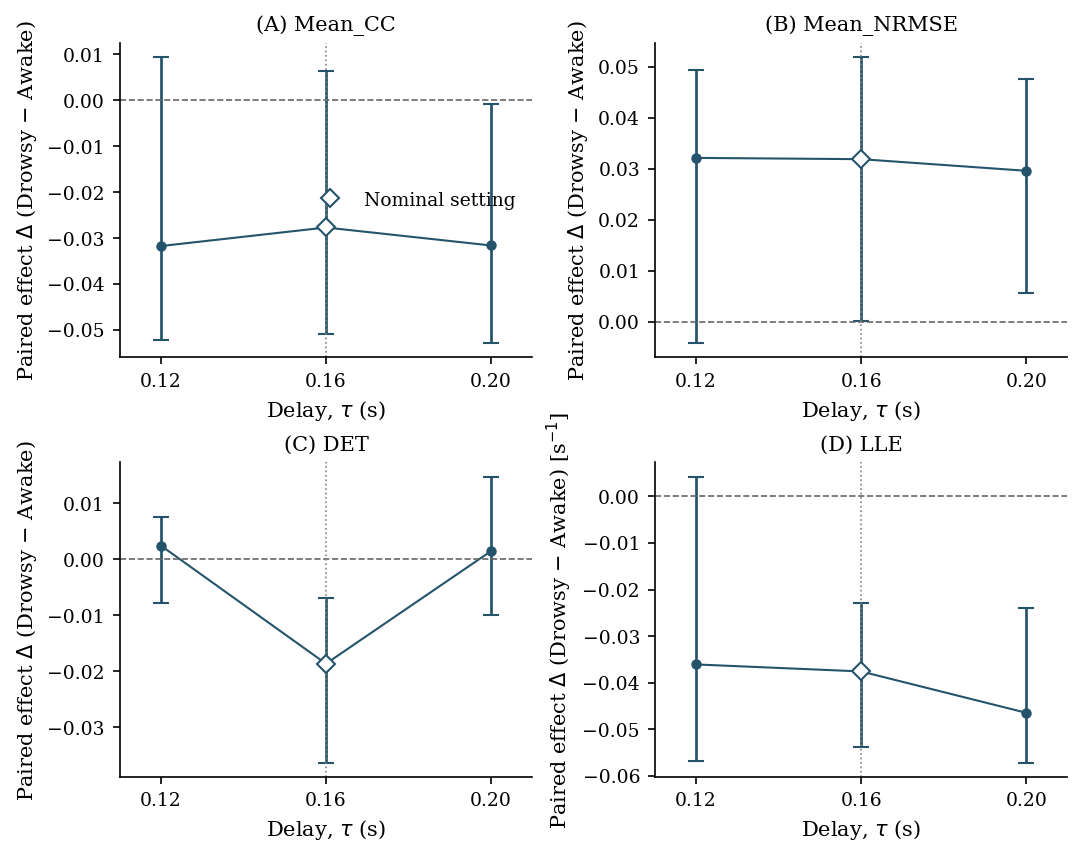

In [ ]:
fig,axes=plt.subplots(2,2,figsize=(7.1,5.6),layout='constrained')
for ax,metric,label in zip(axes.flat,METRICS,'ABCD'):
    s=inference.loc[inference.Metric.eq(metric)].set_index('tau_s').reindex(TAUS)
    # Draw endpoints directly: percentile CIs need not contain the point estimate.
    ax.vlines(TAUS,s.ci_low,s.ci_high,color='#24546b',lw=1.3)
    ax.plot(TAUS,s.median_delta,'o-',color='#24546b',ms=4,lw=1)
    ax.plot(TAUS,s.ci_low,'_',color='#24546b',ms=8)
    ax.plot(TAUS,s.ci_high,'_',color='#24546b',ms=8)
    ax.axhline(0,color='0.4',ls='--',lw=.8)
    ax.axvline(NOMINAL_TAU,color='0.5',ls=':',lw=.8)
    ax.plot([NOMINAL_TAU],[s.loc[NOMINAL_TAU,'median_delta']],marker='D',
            mfc='white',mec='#24546b',ms=6,ls='none',label='Nominal setting')
    ax.set(title=f'({label}) {metric}',xlabel=r'Delay, $\tau$ (s)',
           ylabel=r'Paired effect $\Delta$ (Drowsy $-$ Awake)'+ (' [s$^{-1}$]' if metric=='LLE' else ''))
    ax.set_xticks(TAUS,[f'{t:.2f}' for t in TAUS])
    ax.set_xlim(.11,.21)
axes[0,0].legend(frameon=False)
plt.show()

## 5. m downstream sensitivity — fixed τ=0.16 s

Grid m=7,8,9; nominal m=8 giữ nguyên. Dùng cùng aggregation và statistical framework của phần τ.
Simplex giữ rule k=m+1; RQA giữ rule Theiler=(m−1)×tau_samples. Mỗi metric dùng đúng tập window đạt QC tương ứng.

Bảng statistics và bảng cô đọng giữ effect, CI, p/q, direction count và độ thay đổi magnitude.
Không chọn lại m theo p-value/effect; direction stable không đồng nghĩa mọi metric đều giữ cùng mức hỗ trợ thống kê.

In [ ]:
def dimension_inference(frame,metrics=M_METRICS):
    rows=[]; pair_frames=[]
    for setting_index,dimension in enumerate(M_GRID):
        for mi,metric in enumerate(metrics):
            wide=frame.loc[frame['m'].eq(dimension)].pivot(index='session',columns='state',values=metric)
            wide=wide.reindex(index=M_SESSIONS,columns=['Awake','Drowsy'])
            complete=wide.dropna()
            # Pandas Copy-on-Write may expose a read-only view; zero normalization needs an owned copy.
            d=(complete.Drowsy-complete.Awake).to_numpy(dtype=float, copy=True)
            d[np.isclose(d,0,rtol=0,atol=1e-12)]=0
            n=len(d)
            row=dict(m=dimension,Metric=metric,n=n,
                missing_sessions=', '.join(wide.index[wide.isna().any(axis=1)]))
            if n<2:
                row.update(median_delta=np.nan,ci_low=np.nan,ci_high=np.nan,r_rb=np.nan,p=np.nan,
                           n_expected=int((d*M_EXPECTED_SIGN[metric]>0).sum()),
                           n_reverse=int((d*M_EXPECTED_SIGN[metric]<0).sum()),n_zero=int((d==0).sum()))
            else:
                rng=np.random.default_rng(np.random.SeedSequence([M_SEED,setting_index,M_METRICS.index(metric)]))
                boot=np.median(rng.choice(d,size=(M_BOOTSTRAPS,n),replace=True),axis=1)
                lo,hi=np.percentile(boot,[2.5,97.5]); nonzero=d[d!=0]
                ranks=rankdata(np.abs(nonzero),method='average')
                r_rb=float(np.sum(ranks*np.sign(nonzero))/ranks.sum()) if len(nonzero) else 0.
                p=float(wilcoxon(d,zero_method='wilcox',alternative='two-sided',
                                 correction=False,method='auto').pvalue) if len(nonzero) else 1.
                row.update(median_delta=float(np.median(d)),ci_low=lo,ci_high=hi,r_rb=r_rb,p=p,
                    n_expected=int((d*M_EXPECTED_SIGN[metric]>0).sum()),
                    n_reverse=int((d*M_EXPECTED_SIGN[metric]<0).sum()),n_zero=int((d==0).sum()))
            rows.append(row)
            pair_frames.append(complete.assign(delta=d,m=dimension,Metric=metric).reset_index())
    result=pd.DataFrame(rows)
    result['direction_count']=result.apply(lambda r:f"{r.n_expected}/{r.n} expected; {r.n_reverse} reverse; {r.n_zero} zero",axis=1)
    result['q_BH']=np.nan
    if tuple(metrics)==M_METRICS:
        for dimension,group in result.groupby('m'):
            if group.p.notna().all():
                result.loc[group.index,'q_BH']=bh_four(group.p)
    return result,pd.concat(pair_frames,ignore_index=True)

m_session_state=m_windows.groupby(['m','session','state'],as_index=False)[list(M_METRICS)].median()
m_inference,m_paired_deltas=dimension_inference(m_session_state)
require(len(m_inference)==len(M_GRID)*len(M_METRICS), 'Expected 12 inference rows.')
m_full_table=m_inference[['m','Metric','n','median_delta','ci_low','ci_high','r_rb',
                         'direction_count','p','q_BH','missing_sessions']].copy()
display(m_full_table)

m_compact_rows=[]
for metric in M_METRICS:
    s=m_inference.loc[m_inference.Metric.eq(metric)].set_index('m').reindex(M_GRID)
    effects=s.median_delta.to_numpy(dtype=float,copy=True)
    effects[np.isclose(effects,0,rtol=0,atol=1e-12)]=0
    complete=np.isfinite(effects).all()
    direction_preserved=bool(complete and (effects*M_EXPECTED_SIGN[metric]>0).all())
    nominal=effects[M_GRID.index(M_NOMINAL)]
    has_reversal=bool(complete and np.any(effects*nominal<0))
    row=dict(Metric=metric,**{f'm={m}':effects[i] for i,m in enumerate(M_GRID)},
        direction_preserved=direction_preserved,
        effect_span=float(np.ptp(effects)) if complete else np.nan,
        max_change_relative_to_nominal=(float(np.max(np.abs(effects-nominal))/abs(nominal))
                                       if complete and nominal!=0 else np.nan),
        n_range=f'{s.n.min()}–{s.n.max()}',
        CI_excludes_zero_count=int(((s.ci_low>0)|(s.ci_high<0)).sum()),
        q_below_05_count=int(s.q_BH.lt(.05).sum()))
    if not complete:
        row['Assessment']='Incomplete estimates; cannot assess robustness'
    elif has_reversal:
        row['Assessment']='Sensitive to reconstruction: effect reverses direction'
    elif not direction_preserved:
        row['Assessment']='Expected direction not preserved across all dimensions'
    else:
        row['Assessment']='Direction stable; review effect magnitude, CI and session consistency'
    m_compact_rows.append(row)
m_compact=pd.DataFrame(m_compact_rows)
display(m_compact)

,m,Metric,n,median_delta,ci_low,ci_high,r_rb,direction_count,p,q_BH,missing_sessions
0,7,Mean_CC,20,-0.030651,-0.056483,0.004545,-0.561905,13/20 expected; 7 reverse; 0 zero,0.026642,0.035522,
1,7,Mean_NRMSE,20,0.037698,-0.002297,0.056124,0.571429,13/20 expected; 7 reverse; 0 zero,0.023951,0.035522,
2,7,DET,20,-0.014453,-0.030305,-0.004746,-0.495238,15/20 expected; 5 reverse; 0 zero,0.053169,0.053169,
3,7,LLE,20,-0.028541,-0.054931,-0.007644,-0.695238,16/20 expected; 4 reverse; 0 zero,0.004860,0.019440,
4,8,Mean_CC,20,-0.027705,-0.050898,0.006400,-0.561905,13/20 expected; 7 reverse; 0 zero,0.026642,0.026642,
5,8,Mean_NRMSE,20,0.031855,0.000193,0.051871,0.609524,14/20 expected; 6 reverse; 0 zero,0.015312,0.026642,
6,8,DET,20,-0.018645,-0.036354,-0.006899,-0.580952,15/20 expected; 5 reverse; 0 zero,0.021484,0.026642,
7,8,LLE,20,-0.037570,-0.053698,-0.022976,-0.809524,16/20 expected; 4 reverse; 0 zero,0.000708,0.002831,
8,9,Mean_CC,20,-0.025116,-0.049245,0.005481,-0.552381,13/20 expected; 7 reverse; 0 zero,0.029575,0.039434,
9,9,Mean_NRMSE,20,0.031458,0.004333,0.048332,0.657143,15/20 expected; 5 reverse; 0 zero,0.008308,0.016617,


,Metric,m=7,m=8,m=9,direction_preserved,effect_span,max_change_relative_to_nominal,n_range,CI_excludes_zero_count,q_below_05_count,Assessment
0,Mean_CC,-0.030651,-0.027705,-0.025116,True,0.005535,0.106325,20–20,0,3,"Direction stable; review effect magnitude, CI ..."
1,Mean_NRMSE,0.037698,0.031855,0.031458,True,0.006240,0.183410,20–20,2,3,"Direction stable; review effect magnitude, CI ..."
2,DET,-0.014453,-0.018645,-0.020042,True,0.005589,0.224847,20–20,3,1,"Direction stable; review effect magnitude, CI ..."
3,LLE,-0.028541,-0.037570,-0.024706,True,0.012864,0.342400,20–20,3,3,"Direction stable; review effect magnitude, CI ..."


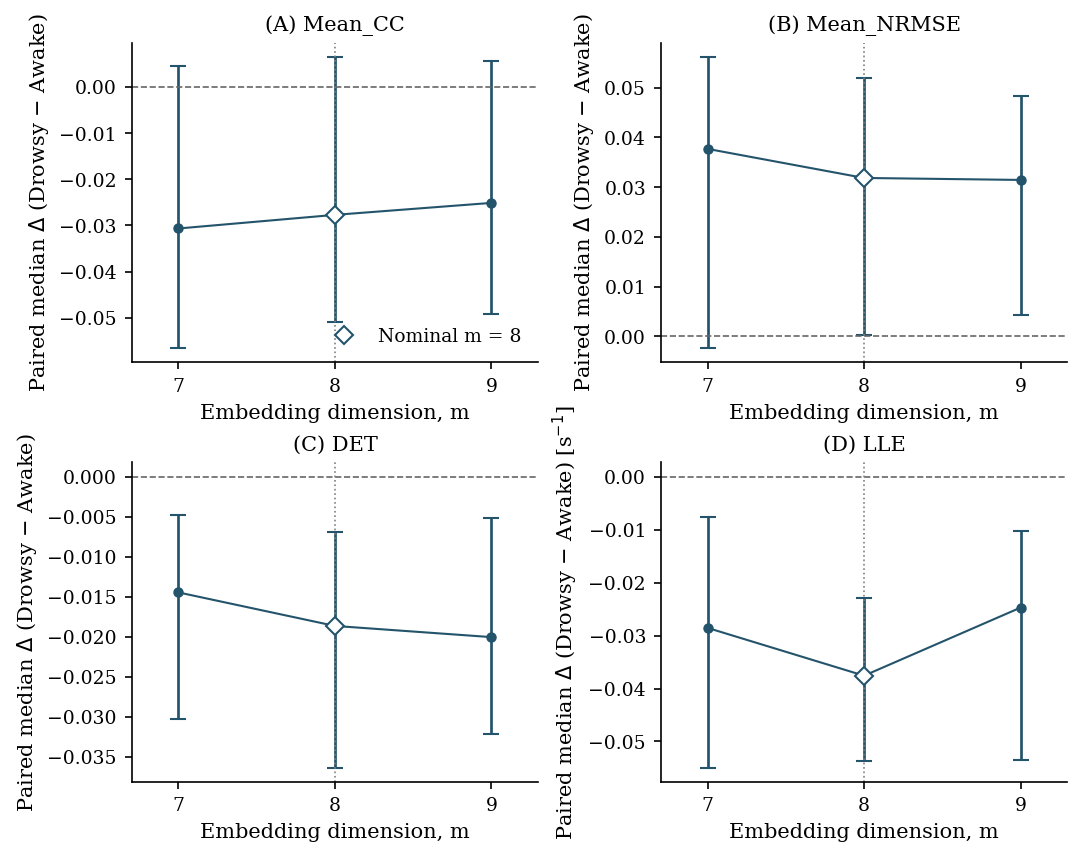

In [32]:
# Inline only; no savefig or figure export.
with mpl.rc_context({'font.family':'serif','font.serif':['DejaVu Serif'],'font.size':10,
    'axes.labelsize':10,'axes.titlesize':10,'xtick.labelsize':9,'ytick.labelsize':9,
    'figure.facecolor':'white','axes.facecolor':'white','axes.grid':False,
    'axes.spines.top':False,'axes.spines.right':False}):
    m_fig,m_axes=plt.subplots(2,2,figsize=(7.1,5.6),layout='constrained')
    for ax,metric,label in zip(m_axes.flat,M_METRICS,'ABCD'):
        s=m_inference.loc[m_inference.Metric.eq(metric)].set_index('m').reindex(M_GRID)
        ax.vlines(M_GRID,s.ci_low,s.ci_high,color='#24546b',lw=1.3)
        ax.plot(M_GRID,s.median_delta,'o-',color='#24546b',ms=4,lw=1)
        ax.plot(M_GRID,s.ci_low,'_',color='#24546b',ms=8)
        ax.plot(M_GRID,s.ci_high,'_',color='#24546b',ms=8)
        ax.axhline(0,color='0.4',ls='--',lw=.8)
        ax.axvline(M_NOMINAL,color='0.5',ls=':',lw=.8)
        ax.plot([M_NOMINAL],[s.loc[M_NOMINAL,'median_delta']],marker='D',mfc='white',
                mec='#24546b',ms=6,ls='none',label='Nominal m = 8')
        ax.set(title=f'({label}) {metric}',xlabel='Embedding dimension, m',
            ylabel=r'Paired median $\Delta$ (Drowsy $-$ Awake)'+(' [s$^{-1}$]' if metric=='LLE' else ''))
        ax.set_xticks(M_GRID); ax.set_xlim(6.7,9.3)
    m_axes[0,0].legend(frameon=False,fontsize=9)
    plt.show()

## 6. Reproducibility / aggregation audit

Audit đã hoàn tất trên dữ liệu/cache, không rerun estimator:

- **901 valid windows** khớp; cùng analysis-included mask trên 951 ứng viên, cùng signal hashes.
- **16.218 horizon rows** và per-window Simplex outputs khớp chính xác; max absolute difference = 0.
- Cùng 20 paired sessions; nominal **m=8, τ=0.16 s tái lập chính xác** khi dùng cùng aggregation, bao gồm CI và BH q.
- Discrepancy trước đây chỉ do đảo thứ tự aggregation: median tại từng horizon rồi mean khác với mean trong window rồi median.
  Notebook này chỉ giữ aggregation chuẩn; nhánh so sánh cũ và các output của nhánh đó đã được loại bỏ.

Cell dưới giữ các kiểm tra nominal cần thiết; output zero-difference được giữ nguyên từ audit đã chạy.

In [ ]:
# Nominal reproducibility from completed window tables; no estimator calls.
audit_keys=['session','state','window_id']
audit_tau=downstream_windows.loc[downstream_windows.tau_s.eq(NOMINAL_TAU)
                                & downstream_windows['m'].eq(M)].set_index(audit_keys).sort_index()
audit_m=m_windows.loc[m_windows.tau_s.eq(M_TAU_S)
                      & m_windows['m'].eq(M_NOMINAL)].set_index(audit_keys).sort_index()
require(len(audit_tau)==len(audit_m)==901 and audit_tau.index.equals(audit_m.index), 'Nominal window IDs differ.')
audit_columns=['fs','n_samples','window_size_s','tau_samples','m','lle_valid',*METRICS]
pd.testing.assert_frame_equal(audit_tau[audit_columns],audit_m[audit_columns],check_exact=True)
nominal_window_max_abs_difference=(audit_tau[list(METRICS)]-audit_m[list(METRICS)]).abs().max().rename('max_abs_difference')
audit_stats=['n','median_delta','ci_low','ci_high','r_rb','p','q_BH']
audit_tau_stats=inference.loc[inference.tau_s.eq(NOMINAL_TAU)].set_index('Metric').reindex(METRICS)
audit_m_stats=m_inference.loc[m_inference['m'].eq(M_NOMINAL)].set_index('Metric').reindex(METRICS)
np.testing.assert_allclose(audit_tau_stats[audit_stats].to_numpy(float),audit_m_stats[audit_stats].to_numpy(float),
                           rtol=1e-12,atol=1e-12,equal_nan=True)
display(nominal_window_max_abs_difference)

Mean_CC       0.0
Mean_NRMSE    0.0
DET           0.0
LLE           0.0
Name: max_abs_difference, dtype: float64

## 7. Final verification summary

**Nominal giữ nguyên: m=8, τ=0.16 s.** Các kết luận dưới đây chỉ cô đọng output đã có; không chọn lại tham số theo p-value/effect.

| Phần | Bằng chứng đã lưu | Verification status |
|---|---|---|
| FNN | Median FNN tại m=8: 0.592818%, 0.885559%, 1.284247% theo τ=0.12/0.16/0.20; số session <1%: 19/20, 11/20, 7/20. FNN giảm mạnh khi tăng m; m=9 không cải thiện nhất quán. | Hỗ trợ vùng m≈8; không đạt <1% đồng đều ở mọi delay/session. |
| τ sensitivity | Mean_CC↓, Mean_NRMSE↑, LLE↓ giữ hướng ở cả ba τ. DET âm tại nominal, nhưng gần 0 và dương tại τ=0.12/0.20. | Độ bền về hướng cho CC/NRMSE/LLE; DET nhạy với delay. |
| m sensitivity | Cả bốn metric giữ hướng tại m=7,8,9, mỗi phép inference có 20 paired sessions. DET có q≈0.0532/0.0266/0.0583; magnitude LLE lệch tối đa 34.2% so với nominal. | Độ bền về hướng trong m=7–9; hỗ trợ thống kê DET và magnitude LLE cần được ghi nhận. |
| Nominal reproducibility | 901 windows, per-window metrics và paired nominal results khớp khi dùng cùng aggregation. | PASS; discrepancy trước đây do aggregation order. |

**Final status: robustness có điều kiện, không phải toàn bộ metric bất biến với reconstruction choice.**
Giữ nominal đã freeze; báo rõ sensitivity của DET theo τ và biến thiên magnitude/hỗ trợ thống kê theo m.
CI và Wilcoxon/BH trả lời các câu hỏi khác nhau: không đánh giá robustness chỉ từ q<0.05.